In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
data = pd.read_csv("C:\\Users\\bingi\\Downloads\\online food delivery dataset.csv")
df = data.copy()
df.head()

,Age,Gender,Marital Status,Occupation,Monthly Income,Educational Qualifications,Family size,Customer Type,latitude,longitude,Pin code,Output,Feedback
0,20,Female,Single,Student,No Income,Post Graduate,4,Frequent,12.9766,77.5993,560001,Yes,Positive
1,24,Female,Single,Student,Below Rs.10000,Graduate,3,Regular,12.9770,77.5773,560009,Yes,Positive
2,22,Male,Single,Student,Below Rs.10000,Post Graduate,3,Regular,12.9551,77.6593,560017,Yes,Negative
3,22,Female,Single,Student,No Income,Graduate,6,Frequent,12.9473,77.5616,560019,Yes,Positive
4,22,Male,Single,Student,Below Rs.10000,Post Graduate,4,Frequent,12.9850,77.5533,560010,Yes,Positive


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 388 entries, 0 to 387
Data columns (total 13 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Age                         388 non-null    int64  
 1   Gender                      388 non-null    object 
 2   Marital Status              388 non-null    object 
 3   Occupation                  388 non-null    object 
 4   Monthly Income              388 non-null    object 
 5   Educational Qualifications  388 non-null    object 
 6   Family size                 388 non-null    int64  
 7   Customer Type               388 non-null    object 
 8   latitude                    388 non-null    float64
 9   longitude                   388 non-null    float64
 10  Pin code                    388 non-null    int64  
 11  Output                      388 non-null    object 
 12  Feedback                    388 non-null    object 
dtypes: float64(2), int64(3), object(8)


In [4]:
df.describe()

,Age,Family size,latitude,longitude,Pin code
count,388.000000,388.000000,388.000000,388.000000,388.000000
mean,24.628866,3.280928,12.972058,77.600160,560040.113402
std,2.975593,1.351025,0.044489,0.051354,31.399609
min,18.000000,1.000000,12.865200,77.484200,560001.000000
25%,23.000000,2.000000,12.936900,77.565275,560010.750000
50%,24.000000,3.000000,12.977000,77.592100,560033.500000
75%,26.000000,4.000000,12.997025,77.630900,560068.000000
max,33.000000,6.000000,13.102000,77.758200,560109.000000


In [5]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error,root_mean_squared_error
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [6]:
y = df['Output']

X = df.drop(columns=['Output'], axis=1)

In [7]:
from sklearn.preprocessing import LabelEncoder
y = LabelEncoder().fit_transform(y)

In [8]:

cat_col = X.select_dtypes(include='object').columns
num_col = X.select_dtypes(exclude='object').columns

num_transformation = Pipeline(steps = [('impute' , SimpleImputer(strategy = 'median')),
                                       ('scaling' , StandardScaler())])

cat_transformation = Pipeline(steps = [('impute' , SimpleImputer(strategy = 'most_frequent')),
                                       ('encoding' , OneHotEncoder(handle_unknown = 'ignore'))])

preprocessor = ColumnTransformer(transformers = [('num' , num_transformation , num_col),
                                               ('cat' , cat_transformation , cat_col)],
                                               remainder = 'drop')
preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. `

In [9]:
X_train , X_test , y_train , y_test = train_test_split(X , y , test_size = 0.2 , random_state = 42)

In [10]:
print('X_train shape:', X_train.shape)
print('X_test shape:', X_test.shape)
print('y_train shape:', y_train.shape)
print('y_test shape:', y_test.shape)

X_train shape: (310, 12)
X_test shape: (78, 12)
y_train shape: (310,)
y_test shape: (78,)


In [11]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier

models = {
    'Logistic Regression' : LogisticRegression(
        C = 0.5,
        solver = 'lbfgs',
        max_iter=1000,
        class_weight='balanced'
    ),

    'Random Forest Classifier' : RandomForestClassifier(
        n_estimators=100,
        max_depth=10,
        min_samples_split=4,
        min_samples_leaf=2,
        max_features='sqrt',
        bootstrap=True,
        random_state=42
    ),

    'Support vector classifier' : SVC(
        C = 0.5,
        kernel = 'rbf',
        gamma='auto',
        probability=True,
        max_iter=1000,
        class_weight='balanced'
    ),

    'KNeighborsClassifier' : KNeighborsClassifier(
        n_neighbors=5,
        weights='distance',
        metric='minkowski',
        p=2
    ),

    'Decision Tree Classfier' : DecisionTreeClassifier(
        max_depth=10,
        min_samples_split=4,
        min_samples_leaf=2,
        criterion='gini',
        splitter='best',
        class_weight='balanced'
    ),

    'XGBoost' : XGBClassifier(
       n_estimators=100,       # number of boosting rounds (trees)
        learning_rate=0.2,      # shrinkage step size
        max_depth=5,            # maximum depth of each tree
        subsample=0.8,          # fraction of samples used per tree
        colsample_bytree=0.8,   # fraction of features used per tree
        gamma=0,                # minimum loss reduction for a split
        reg_alpha=0,            # L1 regularization
        reg_lambda=1,           # L2 regularization
        random_state=42,        # reproducibility
        use_label_encoder=False
    )
}

In [12]:
results = {}

for name, model in models.items():
    print(f'Running model: {name}')
    pipeline = Pipeline(steps = [('preprocessor', preprocessor), ('model', model)])

    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)


    results[name] = {
        'accuracy_score': accuracy_score(y_test, y_pred),
        'confusion_matrix': confusion_matrix(y_test, y_pred),
        'classification_report': classification_report(y_test, y_pred)
    }

for name, result in results.items():
    print(f'Model: {name}')
    print(f'Accuracy Score: {result["accuracy_score"]}')
    print(f'Confusion Matrix:\n{result["confusion_matrix"]}')
    print(f'Classification Report:\n{result["classification_report"]}')
    print('-----------------------------------')

Running model: Logistic Regression
Running model: Random Forest Classifier
Running model: Support vector classifier
Running model: KNeighborsClassifier
Running model: Decision Tree Classfier
Running model: XGBoost


c:\Users\bingi\PycharmProjects\JupyterProject2\.venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [16:53:32] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:794: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Model: Logistic Regression
Accuracy Score: 0.7692307692307693
Confusion Matrix:
[[ 6  6]
 [12 54]]
Classification Report:
              precision    recall  f1-score   support

           0       0.33      0.50      0.40        12
           1       0.90      0.82      0.86        66

    accuracy                           0.77        78
   macro avg       0.62      0.66      0.63        78
weighted avg       0.81      0.77      0.79        78

-----------------------------------
Model: Random Forest Classifier
Accuracy Score: 0.8846153846153846
Confusion Matrix:
[[ 6  6]
 [ 3 63]]
Classification Report:
              precision    recall  f1-score   support

           0       0.67      0.50      0.57        12
           1       0.91      0.95      0.93        66

    accuracy                           0.88        78
   macro avg       0.79      0.73      0.75        78
weighted avg       0.88      0.88      0.88        78

-----------------------------------
Model: Support vector cla

In [13]:
results = {}

for name, model in models.items():
    print(f'Running model: {name}')
    pipeline = Pipeline(steps=[('preprocessor', preprocessor), ('model', model)])

    pipeline.fit(X_train, y_train)
    y_pred_train = pipeline.predict(X_train)   # predictions on training data

    results[name] = {
        'accuracy_score': accuracy_score(y_train, y_pred_train),
        'confusion_matrix': confusion_matrix(y_train, y_pred_train),
        'classification_report': classification_report(y_train, y_pred_train)
    }

for name, result in results.items():
    print(f'Model: {name}')
    print(f'Accuracy Score (Train): {result["accuracy_score"]}')
    print(f'Confusion Matrix (Train):\n{result["confusion_matrix"]}')
    print(f'Classification Report (Train):\n{result["classification_report"]}')
    print('-----------------------------------')


Running model: Logistic Regression
Running model: Random Forest Classifier
Running model: Support vector classifier
Running model: KNeighborsClassifier
Running model: Decision Tree Classfier
Running model: XGBoost


c:\Users\bingi\PycharmProjects\JupyterProject2\.venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [16:53:33] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:794: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Model: Logistic Regression
Accuracy Score (Train): 0.8483870967741935
Confusion Matrix (Train):
[[ 55  20]
 [ 27 208]]
Classification Report (Train):
              precision    recall  f1-score   support

           0       0.67      0.73      0.70        75
           1       0.91      0.89      0.90       235

    accuracy                           0.85       310
   macro avg       0.79      0.81      0.80       310
weighted avg       0.85      0.85      0.85       310

-----------------------------------
Model: Random Forest Classifier
Accuracy Score (Train): 0.9451612903225807
Confusion Matrix (Train):
[[ 60  15]
 [  2 233]]
Classification Report (Train):
              precision    recall  f1-score   support

           0       0.97      0.80      0.88        75
           1       0.94      0.99      0.96       235

    accuracy                           0.95       310
   macro avg       0.95      0.90      0.92       310
weighted avg       0.95      0.95      0.94       310

-----

In [14]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.pipeline import Pipeline

results = {}

for name, model in models.items():
    print(f'Running model: {name}')
    pipeline = Pipeline(steps=[('preprocessor', preprocessor), ('model', model)])
    pipeline.fit(X_train, y_train)

    # Predictions
    y_pred_train = pipeline.predict(X_train)
    y_pred_test  = pipeline.predict(X_test)

    # Accuracy
    train_acc = accuracy_score(y_train, y_pred_train)
    test_acc  = accuracy_score(y_test, y_pred_test)

    # Diagnosis logic
    if train_acc == 1.0 and test_acc < 0.95:
        diagnosis = "Overfitting"
    elif train_acc > 0.95 and (train_acc - test_acc) > 0.1:
        diagnosis = "Overfitting"
    elif train_acc < 0.7 and test_acc < 0.7:
        diagnosis = "Underfitting"
    else:
        diagnosis = "Best Fit"

    # Store results
    results[name] = {
        'train_accuracy': train_acc,
        'test_accuracy': test_acc,
        'train_confusion': confusion_matrix(y_train, y_pred_train),
        'test_confusion': confusion_matrix(y_test, y_pred_test),
        'train_report': classification_report(y_train, y_pred_train),
        'test_report': classification_report(y_test, y_pred_test),
        'diagnosis': diagnosis
    }

# Print results side-by-side
for name, result in results.items():
    print(f'Model: {name}')
    print(f'Train Accuracy: {result["train_accuracy"]:.3f} | Test Accuracy: {result["test_accuracy"]:.3f}')
    print(f'Diagnosis: {result["diagnosis"]}')
    print("\n--- Train Confusion Matrix ---")
    print(result['train_confusion'])
    print("\n--- Test Confusion Matrix ---")
    print(result['test_confusion'])
    print("\n--- Train Classification Report ---")
    print(result['train_report'])
    print("\n--- Test Classification Report ---")
    print(result['test_report'])
    print("=====================================\n")


Running model: Logistic Regression
Running model: Random Forest Classifier
Running model: Support vector classifier
Running model: KNeighborsClassifier
Running model: Decision Tree Classfier
Running model: XGBoost


c:\Users\bingi\PycharmProjects\JupyterProject2\.venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [16:53:35] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:794: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Model: Logistic Regression
Train Accuracy: 0.848 | Test Accuracy: 0.769
Diagnosis: Best Fit

--- Train Confusion Matrix ---
[[ 55  20]
 [ 27 208]]

--- Test Confusion Matrix ---
[[ 6  6]
 [12 54]]

--- Train Classification Report ---
              precision    recall  f1-score   support

           0       0.67      0.73      0.70        75
           1       0.91      0.89      0.90       235

    accuracy                           0.85       310
   macro avg       0.79      0.81      0.80       310
weighted avg       0.85      0.85      0.85       310


--- Test Classification Report ---
              precision    recall  f1-score   support

           0       0.33      0.50      0.40        12
           1       0.90      0.82      0.86        66

    accuracy                           0.77        78
   macro avg       0.62      0.66      0.63        78
weighted avg       0.81      0.77      0.79        78


Model: Random Forest Classifier
Train Accuracy: 0.945 | Test Accuracy: 0.88

In [15]:
from sklearn.cluster import KMeans
from sklearn.cluster import MiniBatchKMeans
from sklearn.metrics import silhouette_score


kmeans = KMeans(n_clusters=3,
                init='k-means++',
                random_state=42)
kmeans.fit(X_train)

ValueError: could not convert string to float: 'Male'

In [ ]:
kmeans.labels_

array([2, 1, 2, 2, 1, 2, 0, 0, 1, 0, 1, 1, 1, 2, 2, 1, 0, 1, 0, 1, 2, 2,
       2, 1, 0, 1, 0, 1, 2, 1, 2, 2, 1, 1, 2, 0, 2, 2, 2, 2, 2, 2, 1, 2,
       1, 2, 1, 1, 2, 2, 1, 1, 1, 2, 2, 0, 1, 1, 2, 2, 2, 1, 2, 2, 2, 0,
       2, 2, 0, 1, 2, 2, 2, 2, 1, 2, 1, 2, 1, 2, 1, 0, 2, 1, 2, 0, 0, 2,
       0, 1, 2, 2, 2, 2, 0, 2, 1, 2, 1, 1, 0, 2, 0, 1, 2, 2, 2, 2, 2, 0,
       0, 1, 2, 2, 1, 2, 0, 2, 2, 2, 2, 1, 1, 2, 2, 1, 0, 2, 1, 2, 2, 0,
       0, 2, 1, 1, 1, 0, 2, 0, 1, 2, 2, 0, 1, 0, 2, 0, 1, 2, 1, 2, 0, 2,
       2, 1, 2, 2, 1, 2, 2, 0, 2, 0, 2, 2, 2, 2, 0, 2, 1, 2, 2, 2, 2, 2,
       1, 2, 1, 0, 2, 2, 2, 2, 0, 2, 2, 1, 2, 2, 0, 0, 1, 2, 2, 0, 2, 2,
       2, 2, 1, 0, 1, 2, 2, 0, 1, 2, 1, 2, 2, 0, 0, 2, 0, 0, 1, 2, 1, 2,
       2, 2, 2, 1, 0, 1, 1, 0, 0, 2, 2, 2, 2, 2, 0, 2, 1, 0, 1, 1, 2, 1,
       2, 1, 2, 2, 0, 1, 2, 2, 2, 2, 2, 2, 1, 1, 2, 0, 2, 2, 0, 2, 1, 2,
       2, 2, 2, 2, 1, 1, 2, 2, 2, 1, 0, 2, 1, 2, 0, 2, 1, 1, 2, 2, 2, 2,
       1, 1, 1, 0, 0, 2, 2, 1, 2, 0, 1, 2, 2, 0, 2,

In [ ]:
score = silhouette_score(X_train, kmeans.labels_)
score

0.15873456341677353

Text(0.5, 1.0, 'Elbow Method For Optimal k')

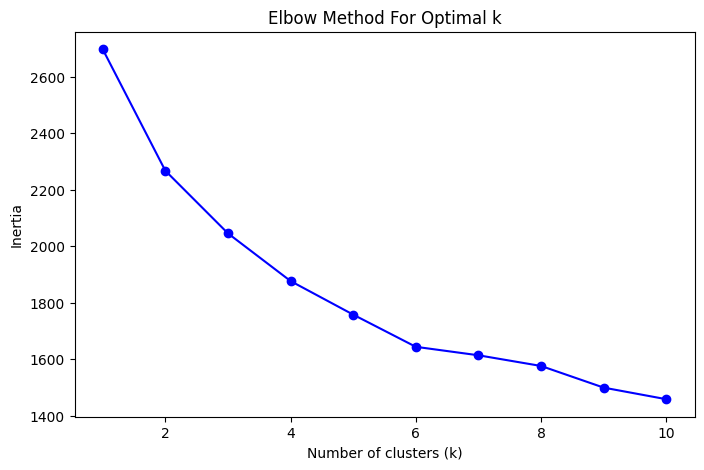

In [ ]:
inertia = []
K = range(1, 11)

for k in K:
    kmeans = KMeans(n_clusters = k,init='k-means++', random_state=42)
    kmeans.fit(X_train)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(K, inertia, 'bo-')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method For Optimal k')


In [ ]:
sample_size = min(200 , X.shape[0])
sample_idx = np.random.choice(X.shape[0] , size = sample_size , replace = False)
X_sample = X.iloc[sample_idx]

X_sample = preprocessor.fit_transform(X_sample)

Silhouette_scores = {}
inertia = {}
K = range(2, 11)

for k in K:
    mini = MiniBatchKMeans(n_clusters=k, init='k-means++',batch_size=100, random_state=42)
    labels = mini.fit_predict(X_sample)

    inertia[k] = mini.inertia_
    Silhouette_scores[k] = silhouette_score(X_sample, labels)

    print(f'k={k}, Inertia={inertia[k]:.2f}, Silhouette Score={Silhouette_scores[k]:.4f}')

best_k = max(Silhouette_scores, key=Silhouette_scores.get)
print(f"\nOptimal number of clusters based on silhouette score: k={best_k}")

k=2, Inertia=1436.93, Silhouette Score=0.1776
k=3, Inertia=1330.10, Silhouette Score=0.1397
k=4, Inertia=1230.07, Silhouette Score=0.1340
k=5, Inertia=1125.15, Silhouette Score=0.1489
k=6, Inertia=1091.03, Silhouette Score=0.1326
k=7, Inertia=1025.15, Silhouette Score=0.1457
k=8, Inertia=956.98, Silhouette Score=0.1570
k=9, Inertia=933.41, Silhouette Score=0.1593
k=10, Inertia=882.09, Silhouette Score=0.1669

Optimal number of clusters based on silhouette score: k=2


In [ ]:
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Define DBSCAN
dbscan = DBSCAN(eps=8, min_samples=5)
labels = dbscan.fit_predict(X_scaled)
print("Clusters:", set(labels))
print("Silhouette Score:", silhouette_score(X_scaled, labels))



Clusters: {np.int64(0), np.int64(-1)}
Silhouette Score: 0.5643714115657641


In [ ]:
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score

best_score = -1
best_params = None

for eps in range(5, 15):          # try eps from 5 to 14
    for min_samples in [3, 5, 10]: # try different min_samples
        db = DBSCAN(eps=eps, min_samples=min_samples)
        labels = db.fit_predict(X_scaled)
        
        # skip if only noise or one cluster
        if len(set(labels)) <= 1 or (set(labels) == {-1}):
            continue
        
        score = silhouette_score(X_scaled, labels)
        if score > best_score:
            best_score = score
            best_params = (eps, min_samples)

print("Best Silhouette Score:", best_score)
print("Best Parameters: eps =", best_params[0], ", min_samples =", best_params[1])


Best Silhouette Score: 0.5643714115657641
Best Parameters: eps = 8 , min_samples = 3


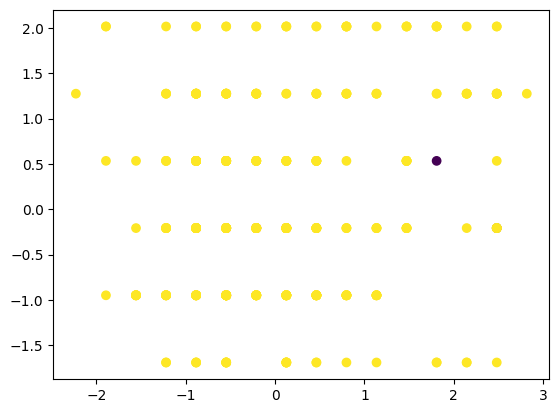

In [ ]:
import matplotlib.pyplot as plt
plt.scatter(X_scaled[:,0], X_scaled[:,1], c=labels, cmap='viridis')
plt.show()


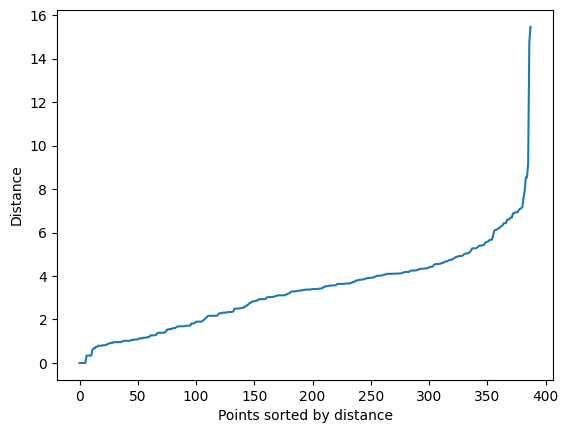

In [ ]:
from sklearn.neighbors import NearestNeighbors
import numpy as np
import matplotlib.pyplot as plt

neigh = NearestNeighbors(n_neighbors=5)
neigh.fit(X_scaled)
distances, indices = neigh.kneighbors(X_scaled)
distances = np.sort(distances[:,4])  # 4th nearest neighbor
plt.plot(distances)
plt.ylabel("Distance")
plt.xlabel("Points sorted by distance")
plt.show()


In [ ]:
from sklearn.decomposition import PCA

X_scaled = preprocessor.fit_transform(X)

pca = PCA(n_components=2)
pca.fit_transform(X_scaled)

array([[-1.54050590e+00,  1.23752485e+00],
       [-9.23604074e-01,  3.86788727e-01],
       [-8.45070884e-01, -5.28143796e-01],
       [-3.47941570e-01,  1.67679377e+00],
       [-1.07374657e+00,  1.39960505e+00],
       [ 1.77379624e+00, -2.57758875e+00],
       [-1.51287909e+00,  2.82072094e-01],
       [-8.93715737e-01, -2.22473946e-01],
       [-1.73823008e+00,  7.24447724e-02],
       [-8.58372073e-02, -1.05680358e-01],
       [-1.04490329e+00,  1.93194554e+00],
       [-1.43149022e+00,  1.54142971e-02],
       [ 1.85727095e-01, -2.44196353e-01],
       [-1.17710662e+00,  1.12002404e+00],
       [-4.80114124e-02,  1.43909986e+00],
       [ 8.67148241e-01, -8.92672021e-02],
       [ 5.38724027e-01, -8.36975639e-01],
       [-1.03470809e+00,  2.08129315e-01],
       [ 6.08094290e-01, -5.80909326e-01],
       [-1.58915113e+00, -1.10858103e+00],
       [-1.28914930e+00,  4.18850324e-01],
       [-1.03994635e+00,  1.16592740e+00],
       [-5.90844382e-01,  6.18303815e-01],
       [-8.

In [ ]:
print(pca.explained_variance_ratio_)
print(sum(pca.explained_variance_ratio_))  # should be <= 1


[0.21367091 0.15158381]
0.3652547224139487


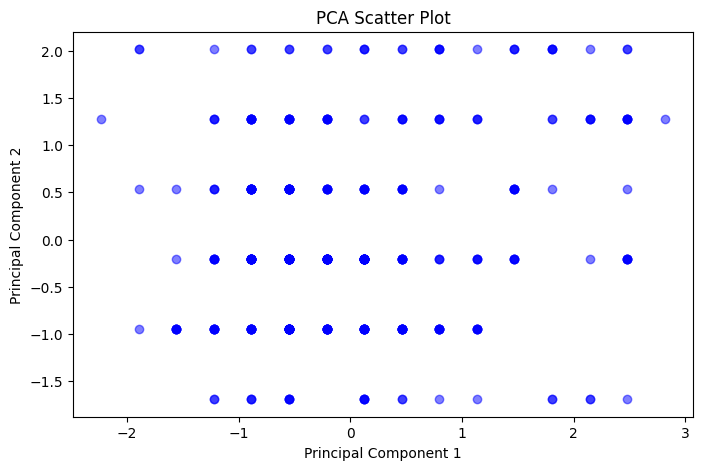

In [ ]:
plt.figure(figsize=(8,5))
plt.scatter(X_scaled[:,0] ,X_scaled[:,1], c='blue', alpha=0.5)
plt.xlabel("Principal Component 1") 
plt.ylabel("Principal Component 2")
plt.title("PCA Scatter Plot")
plt.show()

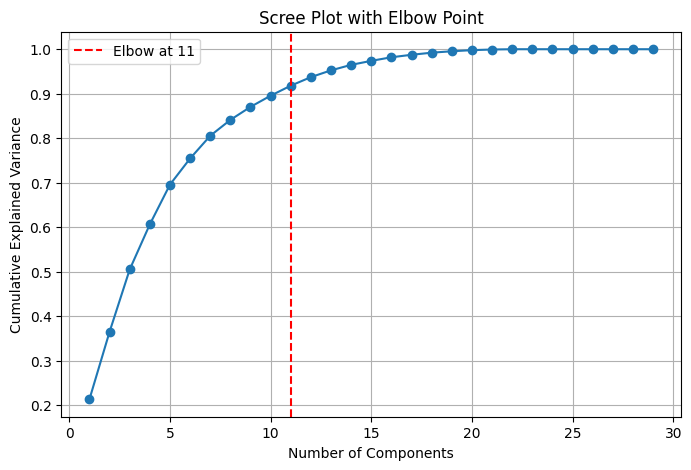

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# Fit PCA on your scaled data
pca_full = PCA().fit(X_scaled)

# Calculate cumulative explained variance
cum_var = np.cumsum(pca_full.explained_variance_ratio_)

# Plot scree plot
plt.figure(figsize=(8,5))
plt.plot(range(1, len(cum_var)+1), cum_var, marker='o')
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Scree Plot with Elbow Point")
plt.grid(True)

# Mark the elbow point (example: first component count where variance > 0.9)
elbow_point = np.argmax(cum_var >= 0.9) + 1
plt.axvline(x=elbow_point, color='r', linestyle='--', label=f'Elbow at {elbow_point}')
plt.legend()

plt.show()


In [ ]:
from sklearn.decomposition import PCA

# Use the elbow point (11 components)
pca_optimal = PCA(n_components=11)
X_reduced = pca_optimal.fit_transform(X_scaled)

print("Shape after PCA:", X_reduced.shape)
print("Cumulative variance explained:", sum(pca_optimal.explained_variance_ratio_))


Shape after PCA: (388, 11)
Cumulative variance explained: 0.9180819996721168


In [ ]:
import pandas as pd

# Get PCA loadings
loadings = pd.DataFrame(
    pca_optimal.components_,
    columns=preprocessor.get_feature_names_out()
)

print(loadings.head())  # first few components


   num__Age  num__Family size  num__latitude  num__longitude  num__Pin code  \
0  0.594131          0.353247      -0.171822        0.233124       0.263137   
1  0.091086          0.524101       0.427124       -0.349129      -0.519842   
2 -0.399693          0.531806      -0.440372        0.347942       0.092420   
3 -0.038980         -0.076829       0.487954        0.807762      -0.265654   
4 -0.087184          0.175352       0.574217       -0.077107       0.758094   

   cat__Gender_Female  cat__Gender_Male  cat__Marital Status_Married  \
0           -0.010884          0.010884                     0.234457   
1            0.046832         -0.046832                     0.044448   
2            0.067662         -0.067662                    -0.107203   
3            0.087033         -0.087033                    -0.027799   
4            0.042910         -0.042910                    -0.064578   

   cat__Marital Status_Prefer not to say  cat__Marital Status_Single  ...  \
0              

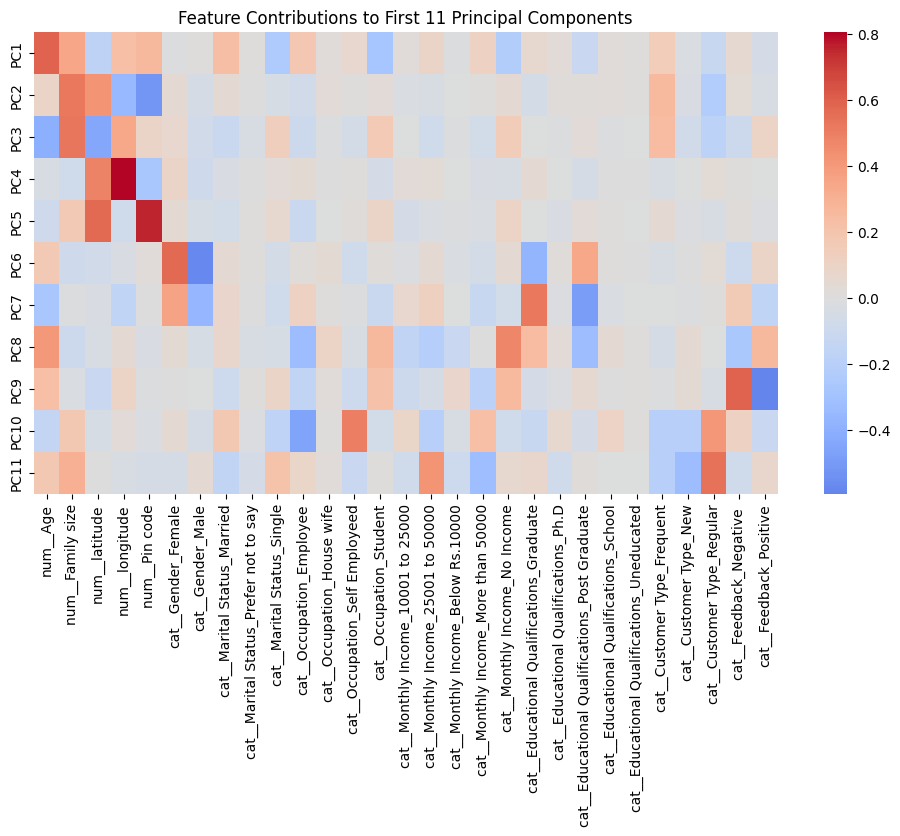

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Create a dataframe of loadings
loadings = pd.DataFrame(
    pca_optimal.components_,
    columns=preprocessor.get_feature_names_out()
)

plt.figure(figsize=(12,6))
sns.heatmap(loadings.iloc[:11], cmap="coolwarm", center=0,
            xticklabels=True, yticklabels=[f"PC{i+1}" for i in range(11)])
plt.title("Feature Contributions to First 11 Principal Components")
plt.show()
